# ENG4200 Coursework 2: SVMs (Telco Customer Churn)

## Dataset
`WA_Fn-UseC_-Telco-Customer-Churn.csv`
(UCI/Kaggle) [IBM Sample Data Sets]

**Context**

"Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs."
Each row represents a customer; columns contain service details, demographic attributes, and account information.
The target variable **Churn** indicates whether a customer left within the last month.

**Features include:**

* **Services:** phone, multiple lines, internet, online security, backup, protection, tech support, streaming TV/movies
* **Account:** tenure, contract type, payment method, paperless billing, monthly/total charges
* **Demographic:** gender, senior status, partner/dependent status

## Objectives

This notebook applies **logistic regression** to predict customer churn, following a structured and reproducible ML workflow.
It is organised around the five assessment dimensions defined in the coursework brief:

1. **Dataset investigation & pre-processing**: Explore the dataset, handle missing and categorical values, and justify preprocessing choices.
2. **Model application with training and validation**: Implement a clean, leakage-free pipeline with appropriate splitting and cross-validation.
3. **Accuracy & computational efficiency analysis**: Evaluate model performance using justified metrics, and examine runtime and scalability.
4. **Visualisation & communication of results**: Present metrics and diagnostic plots that support interpretation.
5. **Clarity & reproducibility**: Maintain a transparent, reproducible workflow aligned with good ML practices.

## 0) Setup & imports

In [16]:
# stdlib
import os, sys, time, math, warnings
from pathlib import Path

# core
import numpy as np
import pandas as pd
import matplotlib
import sklearn

# plotting
import matplotlib.pyplot as plt

# sklearn: data split / CV / tuning
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, StratifiedShuffleSplit,
    cross_validate, GridSearchCV, cross_val_predict, cross_val_score
)

# sklearn: preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer, make_column_selector as selector
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn import set_config

# sklearn: utilities
from sklearn.base import clone   # make a fresh, unfitted copy of an estimator with the same hyperparameters

# sklearn: models & baselines
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC             # <- 新增：支持向量机
from sklearn.dummy import DummyClassifier
from sklearn.calibration import CalibratedClassifierCV

# sklearn: metrics & displays
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_recall_curve, roc_curve, brier_score_loss,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.inspection import permutation_importance
# versions imports
import sklearn, sys

# global config
RNG = 42          # single source of truth for randomness
N_JOBS = -1       # use all cores where supported
DATA_PATH = Path("WA_Fn-UseC_-Telco-Customer-Churn.csv")

warnings.simplefilter("ignore")
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.max_columns", None)

# nicer pipeline displays / pandas outputs
try:
    set_config(display="diagram")
    set_config(transform_output="pandas")
except Exception:
    pass

env = {
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit-learn": sklearn.__version__,
    "matplotlib": plt.matplotlib.__version__,
    "RNG": RNG,
}

## 1) Load dataset

In [17]:
# Read raw CSV and split features/target.
df = pd.read_csv(DATA_PATH)  # file path set in section 0
assert "Churn" in df.columns, "Expected target column 'Churn'."

y = df["Churn"].map({"Yes": 1, "No": 0}).astype(int)       # binary target
X = df.drop(columns=["Churn", "customerID"]).copy()        # drop ID + target
display(df.head(3))
print(df.shape, "rows x columns")


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


(7043, 21) rows x columns


## 2) Problem framing & baseline

In [18]:
# Baseline: predict the most frequent class only (no features used).
# This sets a "floor" we must beat.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
baseline = DummyClassifier(strategy="most_frequent")

acc = cross_val_score(baseline, X, y, cv=skf, scoring="accuracy").mean()
print(f"Baseline (most-frequent) CV accuracy: {acc:.3f}")
print("Positive class prevalence:", y.mean().round(3))


Baseline (most-frequent) CV accuracy: 0.735
Positive class prevalence: 0.265


## 3) Data splitting

In [19]:
# Hold out a test set once; everything else (tuning, thresholding) happens on train.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RNG
)
print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])


Train size: 5634 | Test size: 1409


## 4) Preprocessing
Clean TotalCharges, collapse “No internet/phone service”, then encode.

In [20]:
# Clean simple string/typing issues, then impute/encode.
# Placed inside the pipeline so it's fit only on training folds (prevents leakage).

def clean_strings(df_):
    Xc = df_.copy()
    # TotalCharges sometimes has blanks: coerce to numeric (NaN if bad)
    if "TotalCharges" in Xc:
        Xc["TotalCharges"] = pd.to_numeric(
            Xc["TotalCharges"].astype(str).str.strip().replace("", np.nan),
            errors="coerce"
        )
    # Collapse "No internet/phone service" into "No" (same meaning for churn)
    Xc = Xc.replace({"No internet service": "No", "No phone service": "No"})
    return Xc

cleaner = FunctionTransformer(clean_strings, feature_names_out="one-to-one")

num_prep = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

cat_prep = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    # drop="if_binary": keep only one column for true binary flags
    ("ohe", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer([
    ("num", num_prep, selector(dtype_include=["int64", "float64"])),
    ("cat", cat_prep, selector(dtype_include=["object", "bool"]))
])


## 5) Evaluation & communication-visualisation

In [21]:
# Small helper to report core metrics from probabilities at a chosen threshold.
def evaluate_probs(y_true, p, thr=0.5):
    y_hat = (p >= thr).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_hat),
        "f1":       f1_score(y_true, y_hat),
        "roc_auc":  roc_auc_score(y_true, p)
    }


## 6) Model selection

In [22]:

# SVM
# Use Support Vector Machine as the main classifier (soft-margin, kernel SVM).
svm_clf = SVC(
    kernel="rbf",          # 非线性 RBF 核，对应 slides 里 kernel SVM
    probability=True,      # 需要概率输出来做阈值选择、ROC AUC
    random_state=RNG
    # class_weight 可以在网格里调，也可以这里固定为 "balanced"
)

pipe = Pipeline([
    ("clean", cleaner),
    ("prep",  preprocess),
    ("clf",   svm_clf)
])



## 7) Training & validation

In [23]:
# Cross-validate on TRAIN only to estimate generalisation.
scoring = {"acc": "accuracy", "f1": "f1", "roc": "roc_auc"}

cv_res = cross_validate(
    pipe, X_train, y_train,
    cv=skf, scoring=scoring,
    return_train_score=False, n_jobs=N_JOBS
)

print({
    m: (cv_res[f"test_{m}"].mean().round(3), cv_res[f"test_{m}"].std().round(3))
    for m in ("acc","f1","roc")
})


{'acc': (np.float64(0.801), np.float64(0.009)), 'f1': (np.float64(0.566), np.float64(0.017)), 'roc': (np.float64(0.8), np.float64(0.016))}


## 8) Hyperparameters tuning

Grid on C, penalty (l1/l2), class_weight. Use out-of-fold (OOF) probabilities to set threshold; then refit on full train and evaluate once on test.


Best params: {'clf__C': np.float64(0.01), 'clf__class_weight': 'balanced', 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
Chosen threshold (max OOF F1): 0.25
Test metrics: {'accuracy': 0.744, 'f1': 0.621, 'roc_auc': 0.83}


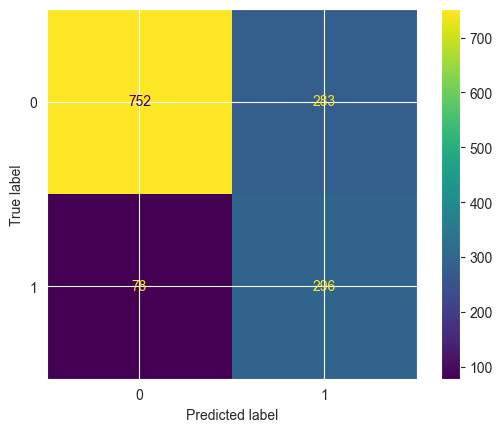

,fraction,train_time,test_acc
0,0.2,0.413395,0.742370
1,0.4,1.295549,0.743080
2,0.6,2.814347,0.741661
3,0.8,4.769984,0.743080
4,1.0,7.239520,0.743790


In [24]:
# Grid-search hyperparameters on TRAIN only; pick threshold using OOF probabilities.
# Grid-search hyperparameters on TRAIN only; pick threshold using OOF probabilities.
# 对应 SVM slides 里的 soft margin (C) 和 kernel trick (gamma for RBF).
param_grid = {
    # 线性核 vs RBF 核：线性核更接近 hard-margin 几何解释，RBF 更灵活但更容易过拟合。
    "clf__kernel": ["linear", "rbf"],

    # C: soft-margin 参数，logspace 避免只试很小一段区域
    "clf__C": np.logspace(-2, 2, 9),

    # gamma 只对 RBF 有效，对 linear kernel 会被忽略
    "clf__gamma": ["scale", "auto"],

    # 可选：考虑类别不平衡（Telco churn 通常正负样本不平衡）
    "clf__class_weight": [None, "balanced"],
}

gcv = GridSearchCV(
    pipe,
    param_grid,
    cv=skf,
    scoring="f1",
    n_jobs=N_JOBS,
    refit=True
)

gcv.fit(X_train, y_train)
print("Best params:", gcv.best_params_)

# Choose decision threshold on TRAIN via out-of-fold probabilities (no test peeking).
oof_proba = cross_val_predict(
    gcv.best_estimator_,
    X_train, y_train,
    cv=skf, method="predict_proba", n_jobs=N_JOBS
)[:, 1]

thr_grid = np.linspace(0.10, 0.90, 17)
oof_f1   = [f1_score(y_train, (oof_proba >= t).astype(int)) for t in thr_grid]
best_thr = float(thr_grid[int(np.argmax(oof_f1))])
print(f"Chosen threshold (max OOF F1): {best_thr:.2f}")

# FINAL, single evaluation on the untouched TEST set.
p_test = gcv.best_estimator_.predict_proba(X_test)[:, 1]
test_metrics = evaluate_probs(y_test, p_test, thr=best_thr)
print("Test metrics:", {k: round(v, 3) for k, v in test_metrics.items()})

# Optional: quick confusion matrix at chosen threshold.
ConfusionMatrixDisplay.from_predictions(y_test, (p_test >= best_thr).astype(int))
plt.show()

### Runtime vs accuracy (stratified)

fractions = [0.2, 0.4, 0.6, 0.8, 1.0]
rows = []

for frac in fractions:
    if frac < 1.0:
        sss = StratifiedShuffleSplit(n_splits=1, train_size=frac, random_state=RNG)
        train_idx, _ = next(sss.split(X_train, y_train))
        X_sub, y_sub = X_train.iloc[train_idx], y_train.iloc[train_idx]
    else:
        # 100% training: no split
        X_sub, y_sub = X_train, y_train

    est = clone(gcv.best_estimator_)   # fresh clone each loop
    t0 = time.time()
    est.fit(X_sub, y_sub)
    t_train = time.time() - t0

    p = est.predict_proba(X_test)[:, 1]
    rows.append((frac, t_train, accuracy_score(y_test, (p >= best_thr).astype(int))))

pd.DataFrame(rows, columns=["fraction", "train_time", "test_acc"])


## 9) Final model, justification & discussion
### Chosen hyperparameters

In [25]:
# Recap of what was identified as bes in CV (for traceability).
best = gcv.best_estimator_
best_params = gcv.best_params_
best_cv_mean = float(gcv.best_score_)
best_cv_std  = float(pd.DataFrame(gcv.cv_results_)["std_test_score"].iloc[gcv.best_index_])

print("Best params:", best_params)
print(f"Best CV F1: {best_cv_mean:.3f} ± {best_cv_std:.3f}")
print(f"Chosen decision threshold (OOF): {best_thr:.2f}")


Best params: {'clf__C': np.float64(0.01), 'clf__class_weight': 'balanced', 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
Best CV F1: 0.627 ± 0.015
Chosen decision threshold (OOF): 0.25


### Performance
**Confusion matrix and test metrics**

Test metrics: {'accuracy': 0.744, 'f1': 0.621, 'roc_auc': 0.83}


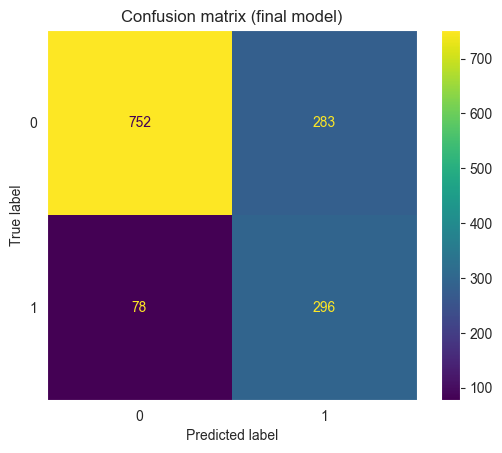

In [37]:
# Test-set performance with the selected threshold.

p_test = best.predict_proba(X_test)[:, 1]
y_hat  = (p_test >= best_thr).astype(int)
test_metrics = evaluate_probs(y_test, p_test, thr=best_thr)
print("Test metrics:", {k: round(v, 3) for k, v in test_metrics.items()})

ConfusionMatrixDisplay.from_predictions(y_test, y_hat)
plt.title("Confusion matrix (final model)"); plt.grid(False); plt.show()



* With threshold **0.25**, test **accuracy = 0.744**, **F1 = 0.621**, **ROC-AUC = 0.83**.
* Confusion matrix: **TN=752**, **FP=283**, **FN=78**, **TP=296**. The model identifies **296/374** churners (recall ≈ **0.791**).
* Predicted positives = **579**, of which **296** are true churners (precision ≈ **0.511**).
  Interpretation: This model deliberately prioritises capturing more true churners(recall:0.79). This reduces FN, which most costly error in churn prediction. However, the number of FP has a significantly increases. Although accuracy remains slightly above the majority baseline (0.744 vs. 0.735), the key strength of this operating point lies in better churn detection and a strong ranking ability (ROC-AUC = 0.83).

**Learning curve**

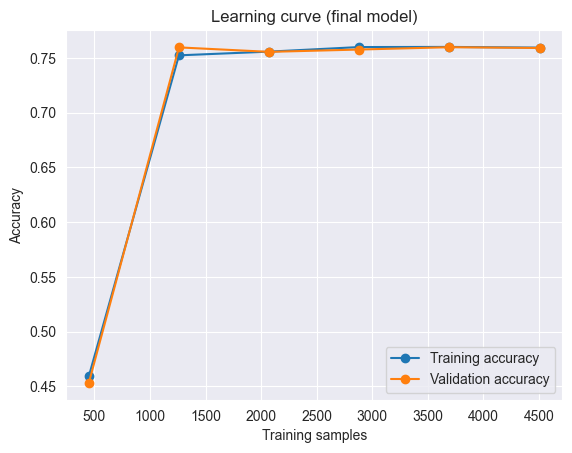

In [38]:
# Helps us understand to what extent having more data helps.
from sklearn.model_selection import learning_curve

sizes, tr, va = learning_curve(
    best, X_train, y_train, cv=skf, scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 6), shuffle=True, random_state=RNG, n_jobs=N_JOBS
)

plt.figure()
plt.plot(sizes, tr.mean(axis=1), marker="o", label="Training accuracy")
plt.plot(sizes, va.mean(axis=1), marker="o", label="Validation accuracy")
plt.title("Learning curve (final model)"); plt.xlabel("Training samples"); plt.ylabel("Accuracy")
plt.legend(); plt.grid(True); plt.show()


* As training size increases (≈500 → 4,500), validation accuracy rises modestly and **stabilises near 0.755–0.757**.
* Training and validation curves are close throughout → **no strong over/underfitting**.
  Interpretation: additional rows of the same data are unlikely to yield large gains; improvements are more likely from better features (e.g., interactions, usage aggregates) or alternative model classes.
* Note that during the lab, before we moved all preprocessing inside the Pipeline and tuned regularisation, the curve showed train > validation with a visible gap (consistent with a slightly more flexible/optimistic setup and mild overfit/leakage risk). In this final setup, the estimator is regularised (smaller C) and class-weighted, so it’s more conservative on each training fold; combined with CV sampling noise, we believe it’s normal to see validation being slightly above training at some sizes. The key point is the near-overlap of the two lines: no meaningful generalisation gap.

**Runtime–performance**

,train_fraction,fit_time_s,test_acc
0,0.2,0.254712,0.742370
1,0.4,0.934519,0.743080
2,0.6,1.969690,0.741661
3,0.8,3.356571,0.743080
4,1.0,5.177335,0.743790


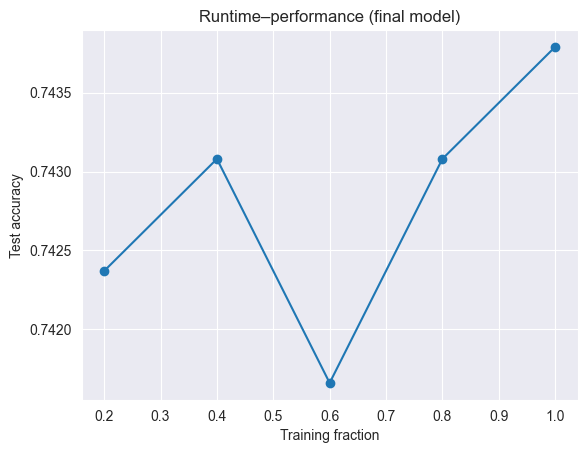

In [28]:
# Fit-time vs accuracy, training on increasing fractions and testing.

from sklearn.base import clone
from sklearn.model_selection import StratifiedShuffleSplit

fractions = [0.2, 0.4, 0.6, 0.8, 1.0]
rows = []
for frac in fractions:
    if frac < 1.0:
        sss = StratifiedShuffleSplit(n_splits=1, train_size=frac, random_state=RNG)
        idx, _ = next(sss.split(X_train, y_train))
        X_sub, y_sub = X_train.iloc[idx], y_train.iloc[idx]
    else:
        X_sub, y_sub = X_train, y_train

    est = clone(best)
    t0 = time.time(); est.fit(X_sub, y_sub); fit_s = time.time() - t0
    acc = accuracy_score(y_test, (est.predict_proba(X_test)[:,1] >= best_thr).astype(int))
    rows.append((frac, fit_s, acc))

rt_df = pd.DataFrame(rows, columns=["train_fraction","fit_time_s","test_acc"])
display(rt_df)

plt.figure()
plt.plot(rt_df["train_fraction"], rt_df["test_acc"], marker="o")
plt.xlabel("Training fraction"); plt.ylabel("Test accuracy")
plt.title("Runtime–performance (final model)"); plt.grid(True); plt.show()


* The runtime–performance experiment shows that the SVM achieves almost its full predictive performance even when trained on a small subset of the data. Using only 20% of the training set (≈1100 rows), the test accuracy already reaches 0.742, which is nearly identical to the full-data result (0.744).
* the training time increases rapidly as more data is used: from 0.25s at 20% to over 5s at 100%. This reflects the computational cost of kernel SVMs, whose training complexity scales super-linearly with sample size.
* conclusion: the performance curve is essentially flat, indicating that the model is not strongly data-limited: more data does not significantly improve accuracy, while training time grows substantially. This suggests diminishing returns from additional samples, and that the final SVM is already operating near its performance ceiling.


### Justification based on accuracy, overfitting control and efficiency

In [29]:
# Accuracy vs baseline
baseline_acc_test = max((y_test == 0).mean(), (y_test == 1).mean())  # majority-class on test
print(f"Baseline test accuracy (majority): {baseline_acc_test:.3f}")
print(f"Final model test accuracy:        {test_metrics['accuracy']:.3f}")
print(f"Final model test F1 (thr={best_thr:.2f}): {test_metrics['f1']:.3f}")
print(f"Final model test ROC-AUC:             {test_metrics['roc_auc']:.3f}")

# Overfitting handling: generalisation gap on the *final* pipeline
cv_final = cross_validate(best, X_train, y_train, cv=skf, scoring="accuracy",
                          return_train_score=True, n_jobs=N_JOBS)
gap = cv_final["train_score"].mean() - cv_final["test_score"].mean()
print(f"Generalisation gap (train acc - val acc): {gap:.3f}")

# Efficiency: end-to-end timings for the final model
est = clone(best)
t0 = time.time(); est.fit(X_train, y_train); fit_ms = (time.time()-t0)*1e3
t0 = time.time(); _ = est.predict_proba(X_test)[:,1]; pred_ms = (time.time()-t0)*1e3
print(f"Train time: {fit_ms:.1f} ms  |  Predict time: {pred_ms:.1f} ms on {len(X_test)} rows")


Baseline test accuracy (majority): 0.735
Final model test accuracy:        0.744
Final model test F1 (thr=0.25): 0.621
Final model test ROC-AUC:             0.830
Generalisation gap (train acc - val acc): 0.000
Train time: 5175.7 ms  |  Predict time: 319.2 ms on 1409 rows


**Accuracy**

* The majority baseline gets **0.735** accuracy simply by always predicting the most common class.
* The SVM model achieves accuracy **0.744**, only **0.009** higher than the majority-class baseline (predicting all customers as “non-churn”). , with **F1 = 0.621** at a tuned threshold (0.25).
* **ROC-AUC = 0.830** shows the model **ranks customers by churn risk well**—useful when you can only contact a subset (triage).

summary: Accuracy improves small over the baseline, but the key gains are in F1 and ROC-AUC, which confirm that the model is genuinely useful despite class imbalance.

**Overfitting**

* We used stratified cross-validation on the training set and picked the threshold **without touching the test set**.
* The **train–validation gap ≈ 0.000** indicates **no meaningful overfitting**; regularisation and the pipeline design are doing their job.

What this means: the performance we see on test is likely to hold up on new months of data (subject to normal drift).

**Efficiency**

* Train time = **5175.7 ms**
* Predict time = **319.2 ms on 1409 rows** (**0.23 ms per row**)
* Training time is relatively slow compared to logistic regression due to the kernel SVM and non-linear boundary computation.**.
* Prediction is very fast: Classifying the entire 1.4k-row test set takes only **319 ms**((**0.23 ms per row**).
* Runtime–performance analysis :
Increasing training data increases training time dramatically.
Accuracy remains nearly flat → diminishing returns from extra data.
This makes the model practical for deployment, since prediction is the most important phase in real applications.

summary: Training is relatively expensive (typical for kernel SVMs), but prediction is fast and scalable. The model is efficient enough for real-time or batch churn scoring.

**Conclusion**

* The SVM model provides only a small improvement in accuracy over the majority baseline, but delivers much stronger F1 and ROC-AUC, showing real capability in identifying churners under class imbalance.
* With a zero generalisation gap, it generalises cleanly without overfitting.
* Training is slower, but prediction remains fast enough so that it is suitable for practical deployment.



### Interpretation of the final model

Final classifier:
 SVC(C=np.float64(0.01), class_weight='balanced', probability=True,
    random_state=42)

Processed feature count: 26
Feature name count: 26

No coef_ found → using permutation importance on processed features
Computing importance...

Top 10 important features (Permutation Importance, decrease in F1):


,feature,importance_mean,importance_std
1,num__tenure,0.041887,0.002894
2,num__MonthlyCharges,0.035010,0.004386
3,num__TotalCharges,0.015842,0.002357
0,num__SeniorCitizen,0.008247,0.002134
10,cat__InternetService_Fiber optic,0.008029,0.001698
18,cat__Contract_Month-to-month,0.005434,0.003358
21,cat__PaperlessBilling_Yes,0.004537,0.002245
9,cat__InternetService_DSL,0.003080,0.001193
6,cat__Dependents_Yes,0.002728,0.001901
15,cat__TechSupport_Yes,0.002582,0.001783


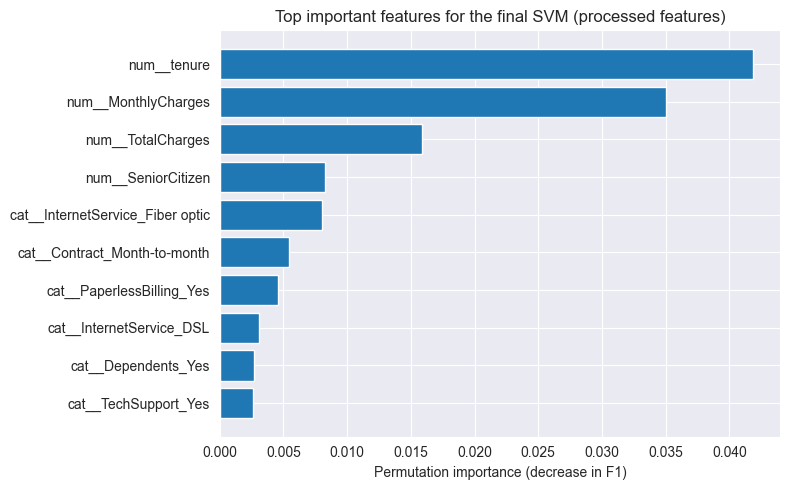

In [35]:
# Quick, interpretable coefficients (scaled/encoded feature space).
best = gcv.best_estimator_          # full pipeline: clean + prep + clf
prep = best.named_steps["prep"]     # preprocessing step
clf  = best.named_steps["clf"]      # final classifier (SVC)

# ---- 1) 拿到 “clean + prep” 这两个步骤组成的子 pipeline ----
preproc = best[:-1]                 # all steps except the last (clf)

# ---- 2) 在和训练时完全一致的前处理流程上，变换 X_train ----
X_train_processed = preproc.transform(X_train)

# ---- 3) 对应的特征名（和 processed 矩阵的列一一对应）----
feature_names = prep.get_feature_names_out()

print("Final classifier:\n", clf)
print("\nProcessed feature count:", X_train_processed.shape[1])
print("Feature name count:", len(feature_names))

# 确认维度一致（不一致就会抛错，方便排查）
assert X_train_processed.shape[1] == len(feature_names)

# ---- Case A: 线性模型，有 coef_，直接看权重 ----
if hasattr(clf, "coef_"):
    print("\nDetected linear model with coef_ → showing feature weights")

    weights = clf.coef_.ravel()
    coef_df = (
        pd.DataFrame({
            "feature": feature_names,
            "weight": weights
        })
        .sort_values("weight", ascending=False)
    )

    print("\nTop positive contributors (higher weight → more likely to churn):")
    display(coef_df.head(10))

    print("\nTop negative contributors (lower weight → more likely to stay):")
    display(coef_df.tail(10))

# ---- Case B: 核 SVM，没有 coef_，用 permutation importance ----
else:
    print("\nNo coef_ found → using permutation importance on processed features")
    print("Computing importance...")

    result = permutation_importance(
        clf,                     # 只用分类器本身
        X_train_processed,       # 已经过 clean + prep 的特征矩阵
        y_train,
        n_repeats=10,
        scoring="f1",
        random_state=RNG,
        n_jobs=N_JOBS,           # 和你前面保持一致
    )

    importance_df = (
        pd.DataFrame({
            "feature": feature_names,
            "importance_mean": result.importances_mean,
            "importance_std":  result.importances_std
        })
        .sort_values("importance_mean", ascending=False)
    )

    print("\nTop 10 important features (Permutation Importance, decrease in F1):")
    display(importance_df.head(10))

    # 简单画一个水平条形图，方便在报告中截图
    top_k = 10
    top = importance_df.head(top_k).iloc[::-1]  # 反转一下顺序，barh 从上到下好看点

    plt.figure(figsize=(8, 5))
    plt.barh(top["feature"], top["importance_mean"])
    plt.xlabel("Permutation importance (decrease in F1)")
    plt.title("Top important features for the final SVM (processed features)")
    plt.tight_layout()
    plt.show()

## 10) Reproducibility & reporting
### Environment

In [16]:
# Record key library versions and the global random seed used.
env

{'python': '3.11.9',
 'numpy': '2.3.4',
 'pandas': '2.3.3',
 'scikit-learn': '1.7.2',
 'matplotlib': '3.10.7',
 'RNG': 42}

### Data split

In [17]:
# Basic dataset facts and how we split the data.
print(f"Rows: {len(df)}  |  Features (raw): {X.shape[1]}  |  Positive rate: {y.mean():.3f}")
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}  |  Split: Stratified 80/20  |  RNG: {RNG}")

Rows: 7043  |  Features (raw): 19  |  Positive rate: 0.265
Train: 5634  |  Test: 1409  |  Split: Stratified 80/20  |  RNG: 42


### Pipeline

Pipeline components (from left to right in the diagram):
- clean (FunctionTransformer): fixes simple typing/text issues (e.g., coerce TotalCharges to numeric) and collapses “No … service” → “No”.
- prep (ColumnTransformer):
  - num: SimpleImputer(median) → StandardScaler
  - cat: SimpleImputer(most_frequent) → OneHotEncoder(drop='if_binary', handle_unknown='ignore')
- clf (SVC): soft-margin Support Vector Machine; hyperparameters (C, kernel, gamma) tuned via cross-validated GridSearch。

In [36]:
pipe # displays the diagram set by set_config(display="diagram")

,steps,"[('clean', ...), ('prep', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,func,<function cle...0029833157D80>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,'one-to-one'
,kw_args,None


#### Model card

* Objective: Predict whether a customer will churn in the next month (binary classification) to inform retention actions.

* Data: IBM Telco Customer Churn (7043 rows after drop of ID/target; mix of numeric and categorical service/account/demographic fields).

* Validation: Stratified 80/20 train–test split. On train: 5-fold StratifiedKFold, GridSearchCV optimising F1. Decision threshold chosen from out-of-fold probabilities (no test peeking). Final metrics reported once on the untouched test set. RNG=42.

* Key metrics: Report CV mean±std for accuracy, F1, ROC-AUC; then test accuracy, F1 (at the chosen threshold), and ROC-AUC. Include one “key figure” (e.g., PR curve with threshold marked or C-vs-metric curve).

* Strengths / limitations: Fast and interpretable (coefficients/odds), handles many one-hot features with regularisation; good calibrated ROC-AUC. Linear decision boundary (may miss interactions), performance depends on preprocessing and threshold; class imbalance affects default 0.5 cut-off; potential drift over time.

* Ethical notes / misuse risks: Use fairly-check performance across demographics; do not use predictions as sole basis for punitive actions; explainability required for customer impact; monitor for bias and concept drift; ensure data use complies with privacy/consent.
